## Notebook 1 – Exploratory Data Analysis and Feature Selection

### Purpose

This notebook performs the initial preparation and exploratory analysis of the 2016 Toronto Neighbourhood Profile dataset.

The objectives of this notebook are to:

- import and inspect the raw dataset;
- evaluate data quality and completeness;
- identify candidate socioeconomic indicators;
- define the dependent (target) and independent (predictor) variables;
- perform feature selection and justification;
- generate a machine-learning-ready dataset for subsequent analyses.

This notebook addresses the first stage of the predictive analytics workflow and provides the foundation for the relationship analysis, dimensionality reduction, clustering, and predictive modelling notebooks.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from ydata_profiling import ProfileReport

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


C:\Users\local_ksalyamova\Temp\ipykernel_15976\3755764946.py:7: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


### Section 2 – Project Input & Output 
### Input

**Dataset**

- Toronto Neighbourhood Profile 2016 (City of Toronto Open Data)
- File: `neighbourhood-profiles-2016-140-model.csv`

The dataset contains demographic, socioeconomic, education, housing, labour market, and population characteristics for all 140 Toronto neighbourhoods.

### Output

This notebook will produce:

- A cleaned and structured machine-learning-ready dataset
- Selected socioeconomic indicators for predictive modelling
- Data quality assessment
- Feature selection justification
- Exploratory data analysis (EDA)
- YData Profiling report
- Exported dataset: `neighbourhood_profiles_2016_ml_ready.csv`

### Data Loading

In [3]:
file_path = "../../data/raw/neighbourhood-profiles-2016-140-model.csv"

df_raw = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print(f"Rows: {df_raw.shape[0]}")
print(f"Columns: {df_raw.shape[1]}")

Dataset loaded successfully.
Rows: 2383
Columns: 146


### Standardize Column Names

The original Toronto Neighbourhood Profile dataset contains column names that differ slightly across dataset versions (*Characteristic* versus *Attribute*).

To maintain consistency throughout this project and ensure that the 2011 and 2016 notebooks follow the same structure, selected column names are standardized immediately after loading the dataset.

Standardizing column names improves code readability, simplifies feature extraction, and allows reusable code across multiple datasets.

In [4]:
df_raw.rename(
    columns={
        "Characteristic": "Attribute"},
    inplace=True)

print("Column names standardized successfully.")

Column names standardized successfully.


### Section 3 – Initial Data Inspection

Before performing data cleaning and feature selection, the raw dataset is examined to understand its overall structure, dimensions, data types, and content.

The objectives of this section are to:

- examine the size and structure of the dataset;
- inspect the first few records;
- identify variable names and data types;
- detect potential inconsistencies or formatting issues;
- establish a baseline understanding of the data before preprocessing.

This initial inspection provides the foundation for the subsequent data quality assessment and feature selection process.

In [5]:
print("=" * 60)
print("Dataset Shape")
print("=" * 60)
print(df_raw.shape)

print("\n")

print("=" * 60)
print("First Five Rows")
print("=" * 60)
display(df_raw.head())

print("\n")

print("=" * 60)
print("Column Names")
print("=" * 60)
display(pd.DataFrame(df_raw.columns, columns=["Column Name"]))

Dataset Shape
(2383, 146)


First Five Rows


,_id,Category,Topic,Data Source,Attribute,City of Toronto,Agincourt North,Agincourt South-Malvern West,Alderwood,Annex,Banbury-Don Mills,Bathurst Manor,Bay Street Corridor,Bayview Village,Bayview Woods-Steeles,Bedford Park-Nortown,Beechborough-Greenbrook,Bendale,Birchcliffe-Cliffside,Black Creek,Blake-Jones,Briar Hill-Belgravia,Bridle Path-Sunnybrook-York Mills,Broadview North,Brookhaven-Amesbury,Cabbagetown-South St. James Town,Caledonia-Fairbank,Casa Loma,Centennial Scarborough,Church-Yonge Corridor,Clairlea-Birchmount,Clanton Park,Cliffcrest,Corso Italia-Davenport,Danforth,Danforth East York,Don Valley Village,Dorset Park,Dovercourt-Wallace Emerson-Junction,Downsview-Roding-CFB,Dufferin Grove,East End-Danforth,Edenbridge-Humber Valley,Eglinton East,Elms-Old Rexdale,Englemount-Lawrence,Eringate-Centennial-West Deane,Etobicoke West Mall,Flemingdon Park,Forest Hill North,Forest Hill South,Glenfield-Jane Heights,Greenwood-Coxwell,Guildwood,Henry Farm,High Park North,High Park-Swansea,Highland Creek,Hillcrest Village,Humber Heights-Westmount,Humber Summit,Humbermede,Humewood-Cedarvale,Ionview,Islington-City Centre West,Junction Area,Keelesdale-Eglinton West,Kennedy Park,Kensington-Chinatown,Kingsview Village-The Westway,Kingsway South,Lambton Baby Point,L'Amoreaux,Lansing-Westgate,Lawrence Park North,Lawrence Park South,Leaside-Bennington,Little Portugal,Long Branch,Malvern,Maple Leaf,Markland Wood,Milliken,Mimico (includes Humber Bay Shores),Morningside,Moss Park,Mount Dennis,Mount Olive-Silverstone-Jamestown,Mount Pleasant East,Mount Pleasant West,New Toronto,Newtonbrook East,Newtonbrook West,Niagara,North Riverdale,North St. James Town,Oakridge,Oakwood Village,O'Connor-Parkview,Old East York,Palmerston-Little Italy,Parkwoods-Donalda,Pelmo Park-Humberlea,Playter Estates-Danforth,Pleasant View,Princess-Rosethorn,Regent Park,Rexdale-Kipling,Rockcliffe-Smythe,Roncesvalles,Rosedale-Moore Park,Rouge,Runnymede-Bloor West Village,Rustic,Scarborough Village,South Parkdale,South Riverdale,St.Andrew-Windfields,Steeles,Stonegate-Queensway,Tam O'Shanter-Sullivan,Taylor-Massey,The Beaches,Thistletown-Beaumond Heights,Thorncliffe Park,Trinity-Bellwoods,University,Victoria Village,Waterfront Communities-The Island,West Hill,West Humber-Clairville,Westminster-Branson,Weston,Weston-Pelham Park,Wexford/Maryvale,Willowdale East,Willowdale West,Willowridge-Martingrove-Richview,Woburn,Woodbine Corridor,Woodbine-Lumsden,Wychwood,Yonge-Eglinton,Yonge-St.Clair,York University Heights,Yorkdale-Glen Park
0,1,Neighbourhood Information,Neighbourhood Information,City of Toronto,Neighbourhood Number,NaN,129,128,20,95,42,34,76,52,49,39,112,127,122,24,69,108,41,57,30,71,109,96,133,75,120,33,123,92,66,59,47,126,93,26,83,62,9,138,5,32,11,13,44,102,101,25,65,140,53,88,87,134,48,8,21,22,106,125,14,90,110,124,78,6,15,114,117,38,105,103,56,84,19,132,29,12,130,17,135,73,115,2,99,104,18,50,36,82,68,74,121,107,54,58,80,45,23,67,46,10,72,4,111,86,98,131,89,28,139,85,70,40,116,16,118,61,63,3,55,81,79,43,77,136,1,35,113,91,119,51,37,7,137,64,60,94,100,97,27,31
1,2,Neighbourhood Information,Neighbourhood Information,City of Toronto,TSNS2020 Designation,NaN,No Designation,No Designation,No Designation,No Designation,No Designation,No Designation,No Designation,No Designation,No Designation,No Designation,NIA,No Designation,No Designation,NIA,No Designation,No Designation,No Designation,No Designation,No Designation,No Designation,No Designation,No Designation,No Designation,No Designation,No Designation,No Designation,No Designation,No Designation,No Designation,No Designation,No Designation,Emerging Neighbourhood,No Designation,NIA,No Designation,No Designation,No Designation,NIA,NIA,Emerging Neighbourhood,No Designation,No Designation,NIA,No Designation,No Designation,NIA,No Designation,No Designation,No Designation,No Designation,No Designation,No Designation,No Designation,Emerging Neighbourhood,NIA,NIA,No Designation,NIA,No Designation,No Designation,NIA,NIA,No Desig



Column Names


,Column Name
0,_id
1,Category
2,Topic
3,Data Source
4,Attribute
...,...
141,Wychwood
142,Yonge-Eglinton
143,Yonge-St.Clair
144,York University Heights


### Section 4 – Data Quality Assessment

Before selecting variables for predictive modelling, the quality of the dataset must be assessed to ensure that the data are complete, consistent, and suitable for analysis.

The objectives of this section are to:

- identify missing values;
- detect duplicate observations;
- examine data types;
- identify invalid or inconsistent values;
- evaluate the overall completeness of the dataset.

This assessment provides an initial understanding of the dataset's quality before more detailed profiling and feature selection are performed.

In [6]:
print("=" * 60)
print("Dataset Information")
print("=" * 60)

df_raw.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2383 entries, 0 to 2382
Columns: 146 entries, _id to Yorkdale-Glen Park
dtypes: int64(1), object(145)
memory usage: 2.7+ MB


### Missing Value Assessment

Missing values can reduce data quality and negatively affect exploratory analysis and predictive modelling.

This assessment identifies variables containing missing values and quantifies the proportion of missing observations within the dataset.

Understanding missingness at this stage helps determine whether variables should be retained, transformed, or excluded during feature selection.

In [7]:
missing_values = (
    df_raw.isnull()
          .sum()
          .to_frame(name="Missing Values"))

missing_values["Missing (%)"] = (
    missing_values["Missing Values"] / len(df_raw) * 100).round(2)

missing_values = missing_values.sort_values(
    by="Missing Values",
    ascending=False)

display(missing_values.head(20))

,Missing Values,Missing (%)
Lansing-Westgate,56,2.35
Lawrence Park North,56,2.35
North Riverdale,56,2.35
North St. James Town,56,2.35
Oakridge,56,2.35
Oakwood Village,56,2.35
O'Connor-Parkview,56,2.35
Old East York,56,2.35
Palmerston-Little Italy,56,2.35
Parkwoods-Donalda,56,2.35


In [8]:
rows_with_missing = df_raw[df_raw.isnull().any(axis=1)]

print(f"Number of indicator rows containing missing values: {len(rows_with_missing)}")

display(
    rows_with_missing[
        ["Category", "Topic", "Attribute"]    ])

Number of indicator rows containing missing values: 62


,Category,Topic,Attribute
0,Neighbourhood Information,Neighbourhood Information,Neighbourhood Number
1,Neighbourhood Information,Neighbourhood Information,TSNS2020 Designation
946,Income,Income of individuals in 2015,Median total income in 2015 among recipien...
948,Income,Income of individuals in 2015,Median after-tax income in 2015 among reci...
951,Income,Income of individuals in 2015,Median market income in 2015 among recipie...
...,...,...,...
1960,Journey to work,Commuting destination,Total - Commuting destination for the employed...
1961,Journey to work,Commuting destination,Commute within census subdivision (CSD) of r...
1962,Journey to work,Commuting destination,Commute to a different census subdivision (C...
1963,Journey to work,Commuting destination,Commute to a different census subdivision (C...


### Interpretation

A total of 62 indicator rows contain one or more missing values.

Most missing values occur in indicators that are not measured for every neighbourhood or represent aggregate statistics rather than neighbourhood-level observations.

The presence of missing values will be considered during feature selection, and only variables with sufficient neighbourhood-level coverage will be retained for predictive modelling.

### Section 5 – Candidate Variable Screening
The objective of this section is to identify and screen candidate socioeconomic variables for inclusion in the machine learning dataset. Rather than selecting predictors solely through automated statistical procedures, a theory-informed screening strategy was adopted to ensure that retained variables are relevant, consistently defined, and suitable for temporal analysis.

Candidate variables were identified from the Toronto Neighbourhood Profiles and evaluated according to predefined screening criteria before feature extraction. Statistical assessment of the retained variables is conducted separately in Notebook 2..

The Toronto Neighbourhood Profiles contain more than 2,300 indicator records, with each socioeconomic indicator stored as a separate row. To simplify variable identification and reduce manual searching, the `find_indicator()` helper function performs a keyword search within the **Attribute** column and returns all matching indicators. This allows candidate variables to be verified before they are extracted and transformed into the machine-learning-ready dataset.

In [9]:
def find_indicator(keyword):
    """
    Search the Attribute column for a keyword.
    """
    results = df_raw[
        df_raw["Attribute"].str.contains(keyword, case=False, na=False)  ]

    return results[["Category", "Topic", "Attribute"]]

### 5.1 Population

In [10]:
find_indicator("Population, 2016")

,Category,Topic,Attribute
2,Population,Population and dwellings,"Population, 2016"


### 5.2 Labour Force Indicators

In [11]:
find_indicator("Participation rate")

,Category,Topic,Attribute
1888,Labour,Labour force status,Participation rate
1896,Labour,Labour force status,Participation rate (Males)
1904,Labour,Labour force status,Participation rate (Females)


In [12]:
find_indicator("Employment rate")

,Category,Topic,Attribute
1889,Labour,Labour force status,Employment rate
1890,Labour,Labour force status,Unemployment rate
1897,Labour,Labour force status,Employment rate (Males)
1898,Labour,Labour force status,Unemployment rate (Males)
1905,Labour,Labour force status,Employment rate (Females)
1906,Labour,Labour force status,Unemployment rate (Females)


In [13]:
find_indicator("Unemployment rate")

,Category,Topic,Attribute
1890,Labour,Labour force status,Unemployment rate
1898,Labour,Labour force status,Unemployment rate (Males)
1906,Labour,Labour force status,Unemployment rate (Females)


### 5.3 Educational Attainment

In [14]:
find_indicator("Bachelor")

,Category,Topic,Attribute
1708,Education,"Highest certificate, diploma or degree",University certificate or diploma below ba...
1709,Education,"Highest certificate, diploma or degree","University certificate, diploma or degree ..."
1710,Education,"Highest certificate, diploma or degree",Bachelor's degree
1711,Education,"Highest certificate, diploma or degree",University certificate or diploma above ...
1723,Education,"Highest certificate, diploma or degree",University certificate or diploma below ba...
1724,Education,"Highest certificate, diploma or degree","University certificate, diploma or degree ..."
1725,Education,"Highest certificate, diploma or degree",Bachelor's degree
1726,Education,"Highest certificate, diploma or degree",University certificate or diploma above ...


In [15]:
find_indicator("No certificate")

,Category,Topic,Attribute
1703,Education,"Highest certificate, diploma or degree","No certificate, diploma or degree"
1715,Education,"Highest certificate, diploma or degree","No certificate, diploma or degree"


### 5.4 Immigration

In [16]:
find_indicator("Immigrants")

,Category,Topic,Attribute
1151,Immigration and citizenship,Immigrant status and period of immigration,Non-immigrants
1152,Immigration and citizenship,Immigrant status and period of immigration,Immigrants
1296,Immigration and citizenship,Admission category and applicant type,Economic immigrants
1299,Immigration and citizenship,Admission category and applicant type,Immigrants sponsored by family
1301,Immigration and citizenship,Admission category and applicant type,Other immigrants


### 5.5 Visible Minority

In [17]:
find_indicator("Visible")

,Category,Topic,Attribute
1335,Visible minority,Visible minority population,Total - Visible minority for the population in...
1336,Visible minority,Visible minority population,Total visible minority population
1346,Visible minority,Visible minority population,Visible minority; n.i.e.
1347,Visible minority,Visible minority population,Multiple visible minorities
1348,Visible minority,Visible minority population,Not a visible minority


### 5.6 Housing Indicators

In [18]:
find_indicator("Rent")

,Category,Topic,Attribute
94,"Families, households and marital status",Family characteristics,Total lone-parent families by sex of parent
95,"Families, households and marital status",Family characteristics,Female parent
96,"Families, households and marital status",Family characteristics,Male parent
102,"Families, households and marital status",Family characteristics,Lone-parent census families in private households
1081,Income,Income of economic families in 2015,Total - Income statistics in 2015 for lone-par...
1088,Income,Income of economic families in 2015,Median total income of lone-parent economic ...
1089,Income,Income of economic families in 2015,Median after-tax income of lone-parent econo...
1090,Income,Income of economic families in 2015,Average family size of lone-parent economic ...
1101,Income,Income of economic families in 2015,Total - Income statistics in 2015 for lone-par...
1102,Income,Income of economic families in 2015,Average total income of lone-parent economic...


In [19]:
find_indicator("Core housing")

,Category,Topic,Attribute
1681,Housing,Core housing need,Rate of core housing need
1682,Housing,Core housing need,Number of households in core housing need
1684,Housing,Core housing need,"Core housing need, Unsuitable only"
1685,Housing,Core housing need,"Core housing need, Inadequate only"
1686,Housing,Core housing need,"Core housing need, Unaffordable only"
1687,Housing,Core housing need,"Core housing need, two or more dimensions"


In [20]:
find_indicator("Unaffordable")

,Category,Topic,Attribute
1686,Housing,Core housing need,"Core housing need, Unaffordable only"
1688,Housing,Core housing need,Rate of unaffordable housing
1689,Housing,Core housing need,Unaffordable housing not in core need
1690,Housing,Core housing need,Unaffordable housing in core need
1691,Housing,Core housing need,Unaffordable housing not applicable for core need
1692,Housing,Core housing need,"Rate of unaffordable housing, owner-households"
1693,Housing,Core housing need,"Rate of unaffordable housing, renter-households"


### 5.7 Family Structure

In [21]:
find_indicator("lone-parent")

,Category,Topic,Attribute
94,"Families, households and marital status",Family characteristics,Total lone-parent families by sex of parent
102,"Families, households and marital status",Family characteristics,Lone-parent census families in private households
1081,Income,Income of economic families in 2015,Total - Income statistics in 2015 for lone-par...
1088,Income,Income of economic families in 2015,Median total income of lone-parent economic ...
1089,Income,Income of economic families in 2015,Median after-tax income of lone-parent econo...
1090,Income,Income of economic families in 2015,Average family size of lone-parent economic ...
1101,Income,Income of economic families in 2015,Total - Income statistics in 2015 for lone-par...
1102,Income,Income of economic families in 2015,Average total income of lone-parent economic...
1103,Income,Income of economic families in 2015,Average after-tax income of lone-parent econ...


### 5.8 Dependent Variable

In [22]:
find_indicator("low")

,Category,Topic,Attribute
1120,Income,Low income in 2015,Total - Low-income status in 2015 for the popu...
1125,Income,Low income in 2015,"In low income based on the Low-income measure,..."
1130,Income,Low income in 2015,Prevalence of low income based on the Low-inco...
1133,Income,Low income in 2015,In low income based on the Low-income cut-offs...
1139,Income,Low income in 2015,Prevalence of low income based on the Low-inco...
1708,Education,"Highest certificate, diploma or degree",University certificate or diploma below ba...
1723,Education,"Highest certificate, diploma or degree",University certificate or diploma below ba...
2304,Income,Income sources,Guaranteed Income Supplement (GIS) and s...
2305,Income,Income sources,Guaranteed Income Supplement (GIS) and s...
2307,Income,Income sources,Guaranteed Income Supplement (GIS) and s...


In [23]:
find_indicator("after-tax")

,Category,Topic,Attribute
947,Income,Income of individuals in 2015,Number of after-tax income recipients aged 1...
948,Income,Income of individuals in 2015,Median after-tax income in 2015 among reci...
960,Income,Income of individuals in 2015,Number of after-tax income recipients aged 1...
961,Income,Income of individuals in 2015,Average after-tax income in 2015 among rec...
984,Income,Income of individuals in 2015,Total - After-tax income groups in 2015 for th...
985,Income,Income of individuals in 2015,Without after-tax income
986,Income,Income of individuals in 2015,With after-tax income
987,Income,Income of individuals in 2015,Percentage with after-tax income
1019,Income,Income of households in 2015,Median after-tax income of households in 201...
1022,Income,Income of households in 2015,Median after-tax income of one-person ho...


### Interpretation

The candidate feature assessment confirmed that multiple neighbourhood-level socioeconomic indicators are available within the 2016 Toronto Neighbourhood Profile.

Each candidate variable was reviewed to verify its availability, completeness, and relevance for predictive modelling. Variables representing labour market conditions, educational attainment, immigration, visible minority population, housing conditions, family structure, and neighbourhood-level low-income prevalence were successfully identified.

The assessment also confirmed that some indicators available in earlier Census Profiles, such as median individual income and median after-tax income, are not consistently reported at the neighbourhood level in the 2016 dataset. Consequently, only variables with complete neighbourhood-level coverage will be retained for the final modelling dataset.

The verified indicators will now be organized into the final feature set for extraction and transformation.

### Section 6 – Final Feature Selection

Following the candidate feature assessment, the final set of socioeconomic indicators is selected for predictive modelling.

Variables were retained based on four criteria:

- availability at the neighbourhood level;
- completeness and quality of the data;
- consistency with the 2011 Toronto Neighbourhood Profile where possible;
- relevance to neighbourhood socioeconomic vulnerability.

The selected variables consist of one target variable and multiple predictor variables that will be extracted and transformed into the final machine learning dataset.

In [24]:
feature_mapping = {

    "Population": 2,

    "Participation_Rate": 1888,
    "Employment_Rate": 1889,
    "Unemployment_Rate": 1890,

    "Bachelors_Degree": 1710,
    "No_Diploma": 1704,

    "Immigrant_Population": 1152,
    "Visible_Minority": 1336,

    "Renters": 1629,
    "Core_Housing_Need": 1682,      
    "Unaffordable_Housing": 1688,

    "Lone_Parent_Families": 102,

    "Low_Income_AfterTax_Pct": 1130}

In [25]:
feature_table = (pd.DataFrame({"Research Variable": feature_mapping.keys(), "Source Row": feature_mapping.values()}))

display(feature_table)

,Research Variable,Source Row
0,Population,2
1,Participation_Rate,1888
2,Employment_Rate,1889
3,Unemployment_Rate,1890
4,Bachelors_Degree,1710
5,No_Diploma,1704
6,Immigrant_Population,1152
7,Visible_Minority,1336
8,Renters,1629
9,Core_Housing_Need,1682


#### Interpretation

A final set of 13 research variables was selected for predictive modelling, consisting of 12 independent variables and one dependent variable (Low_Income_AfterTax_Pct). Together with the Neighbourhood identifier, these variables form the machine learning-ready dataset used in the subsequent analyses.

The selected predictors capture labour market participation, income, educational attainment, immigration, visible minority status, housing conditions, family structure, and population characteristics.

These variables provide a comprehensive representation of neighbourhood vulnerability while maintaining compatibility with the 2011 Toronto Neighbourhood Profile for the predictive modelling stage.

The following section extracts the selected indicators and constructs the modelling dataset.

### 6.2 Selection of the Dependent Variable

The dependent variable selected for this study is **Low_Income_AfterTax_Pct (LIA-Tax%)**, representing the percentage of neighbourhood residents living below the **Statistics Canada Low-Income Measure, After-Tax (LIM-AT)**.

The selection of this variable was guided by both the study objectives and the social vulnerability literature. Cutter, Boruff, and Shirley (2003) describe social vulnerability as a multidimensional concept influenced by demographic, socioeconomic, educational, housing, labour market, and household characteristics. Within this framework, neighbourhood low-income prevalence represents an appropriate outcome because it reflects an important dimension of socioeconomic disadvantage that may be explained by these community characteristics.

LIA-Tax% is derived from the official Statistics Canada Low-Income Measure, After-Tax (LIM-AT), a nationally recognized indicator of relative low-income status. Furthermore, this variable is consistently available in both the 2011 and 2016 Toronto Neighbourhood Profiles datasets, enabling cross-sectional modelling and supporting the temporal validation conducted later in this study.

Accordingly, **Low_Income_AfterTax_Pct** is treated as the **dependent variable** and used as a **proxy indicator of neighbourhood socioeconomic vulnerability**, while recognizing that neighbourhood vulnerability is a broader multidimensional concept that cannot be fully represented by a single socioeconomic indicator.

**References**

- Cutter, S. L., Boruff, B. J., & Shirley, W. L. (2003). *Social vulnerability to environmental hazards*. Social Science Quarterly, 84(2), 242–261.
- Statistics Canada. (2016). *Census Dictionary – Low-Income Measure, After-Tax (LIM-AT).*

### Section 7 – Feature Extraction
Using the finalized feature mapping, the corresponding indicators are extracted from the 2016 Toronto Neighbourhood Profile.

Only the selected socioeconomic variables required for predictive modelling are retained. The resulting dataset will serve as the foundation for the machine learning-ready neighbourhood dataset.

### 7.1 Feature Extraction

In [26]:
selected_df = df_raw.loc[
    list(feature_mapping.values())].copy()

print("=" * 60)
print("FEATURE EXTRACTION SUMMARY")
print("=" * 60)

print(f"\nSelected variables: {selected_df.shape[0]}")
print(f"Columns: {selected_df.shape[1]}")

display(selected_df[["_id", "Category", "Topic", "Attribute"]   ])

FEATURE EXTRACTION SUMMARY

Selected variables: 13
Columns: 146


,_id,Category,Topic,Attribute
2,3,Population,Population and dwellings,"Population, 2016"
1888,1889,Labour,Labour force status,Participation rate
1889,1890,Labour,Labour force status,Employment rate
1890,1891,Labour,Labour force status,Unemployment rate
1710,1711,Education,"Highest certificate, diploma or degree",Bachelor's degree
1704,1705,Education,"Highest certificate, diploma or degree",Secondary (high) school diploma or equivalen...
1152,1153,Immigration and citizenship,Immigrant status and period of immigration,Immigrants
1336,1337,Visible minority,Visible minority population,Total visible minority population
1629,1630,Housing,Household characteristics,Renter
1682,1683,Housing,Core housing need,Number of households in core housing need


### 7.2 Remove Metadata

The selected indicators still contain descriptive metadata used for documentation purposes.

For machine learning, only the neighbourhood-level values are required. Therefore, the metadata columns are removed while preserving the selected socioeconomic indicators.

In [27]:
model_data = selected_df.iloc[:, 4:].copy()

print("=" * 60)
print("MODEL DATA")
print("=" * 60)

print(model_data.shape)

display(model_data.head())

MODEL DATA
(13, 142)


,Attribute,City of Toronto,Agincourt North,Agincourt South-Malvern West,Alderwood,Annex,Banbury-Don Mills,Bathurst Manor,Bay Street Corridor,Bayview Village,Bayview Woods-Steeles,Bedford Park-Nortown,Beechborough-Greenbrook,Bendale,Birchcliffe-Cliffside,Black Creek,Blake-Jones,Briar Hill-Belgravia,Bridle Path-Sunnybrook-York Mills,Broadview North,Brookhaven-Amesbury,Cabbagetown-South St. James Town,Caledonia-Fairbank,Casa Loma,Centennial Scarborough,Church-Yonge Corridor,Clairlea-Birchmount,Clanton Park,Cliffcrest,Corso Italia-Davenport,Danforth,Danforth East York,Don Valley Village,Dorset Park,Dovercourt-Wallace Emerson-Junction,Downsview-Roding-CFB,Dufferin Grove,East End-Danforth,Edenbridge-Humber Valley,Eglinton East,Elms-Old Rexdale,Englemount-Lawrence,Eringate-Centennial-West Deane,Etobicoke West Mall,Flemingdon Park,Forest Hill North,Forest Hill South,Glenfield-Jane Heights,Greenwood-Coxwell,Guildwood,Henry Farm,High Park North,High Park-Swansea,Highland Creek,Hillcrest Village,Humber Heights-Westmount,Humber Summit,Humbermede,Humewood-Cedarvale,Ionview,Islington-City Centre West,Junction Area,Keelesdale-Eglinton West,Kennedy Park,Kensington-Chinatown,Kingsview Village-The Westway,Kingsway South,Lambton Baby Point,L'Amoreaux,Lansing-Westgate,Lawrence Park North,Lawrence Park South,Leaside-Bennington,Little Portugal,Long Branch,Malvern,Maple Leaf,Markland Wood,Milliken,Mimico (includes Humber Bay Shores),Morningside,Moss Park,Mount Dennis,Mount Olive-Silverstone-Jamestown,Mount Pleasant East,Mount Pleasant West,New Toronto,Newtonbrook East,Newtonbrook West,Niagara,North Riverdale,North St. James Town,Oakridge,Oakwood Village,O'Connor-Parkview,Old East York,Palmerston-Little Italy,Parkwoods-Donalda,Pelmo Park-Humberlea,Playter Estates-Danforth,Pleasant View,Princess-Rosethorn,Regent Park,Rexdale-Kipling,Rockcliffe-Smythe,Roncesvalles,Rosedale-Moore Park,Rouge,Runnymede-Bloor West Village,Rustic,Scarborough Village,South Parkdale,South Riverdale,St.Andrew-Windfields,Steeles,Stonegate-Queensway,Tam O'Shanter-Sullivan,Taylor-Massey,The Beaches,Thistletown-Beaumond Heights,Thorncliffe Park,Trinity-Bellwoods,University,Victoria Village,Waterfront Communities-The Island,West Hill,West Humber-Clairville,Westminster-Branson,Weston,Weston-Pelham Park,Wexford/Maryvale,Willowdale East,Willowdale West,Willowridge-Martingrove-Richview,Woburn,Woodbine Corridor,Woodbine-Lumsden,Wychwood,Yonge-Eglinton,Yonge-St.Clair,York University Heights,Yorkdale-Glen Park
2,"Population, 2016","2,731,571","29,113","23,757","12,054","30,526","27,695","15,873","25,797","21,396","13,154","23,236","6,577","29,960","22,291","21,737","7,727","14,257","9,266","11,499","17,757","11,669","9,955","10,968","13,362","31,340","26,984","16,472","15,935","14,133","9,666","17,180","27,051","25,003","36,625","35,052","11,785","21,381","15,535","22,776","9,456","22,372","18,588","11,848","21,933","12,806","10,732","30,491","14,417","9,917","15,723","22,162","23,925","12,494","16,934","10,948","12,416","15,545","14,365","13,641","43,965","14,366","11,058","17,123","17,945","22,000","9,271","7,985","43,993","16,164","14,607","15,179","16,828","15,559","10,084","43,794","10,111","10,554","26,572","33,964","17,455","20,506","13,593","32,954","16,775","29,658","11,463","16,097","23,831","31,180","11,916","18,615","13,845","21,210","18,675","9,233","13,826","34,805","10,722","7,804","15,818","11,051","10,803","10,529","22,246","14,974","20,923","46,496","10,070","9,941","16,724","21,849","27,876","17,812","24,623","25,051","27,446","15,683","21,567","10,360","21,108","16,556","7,607","17,510","65,913","27,392","33,312","26,274","17,992","11,098","27,917","50,434","16,936","22,156","53,485","12,541","7,865","14,349","11,817","12,528","27,593","14,804"
1888,Participation rate,64.7,55.4,59,66.5,70.6,59.9,65,62.7,63.4,55.7,63.8,59.5,58,65.4,54.8,65,67.6,58.3,66.5,63.5,71.3,65.9,67.2,64.2,75.1,65.3,67.9,61.9,68.1,68.5,67,61,63.3,70.3,61.7,72.4,70.1,64.4,59.2,60.7,63,63.6,65.7,56.

In [28]:
model_data = model_data.drop(columns=["Attribute"])

print(model_data.shape)

display(model_data.head())

(13, 141)


,City of Toronto,Agincourt North,Agincourt South-Malvern West,Alderwood,Annex,Banbury-Don Mills,Bathurst Manor,Bay Street Corridor,Bayview Village,Bayview Woods-Steeles,Bedford Park-Nortown,Beechborough-Greenbrook,Bendale,Birchcliffe-Cliffside,Black Creek,Blake-Jones,Briar Hill-Belgravia,Bridle Path-Sunnybrook-York Mills,Broadview North,Brookhaven-Amesbury,Cabbagetown-South St. James Town,Caledonia-Fairbank,Casa Loma,Centennial Scarborough,Church-Yonge Corridor,Clairlea-Birchmount,Clanton Park,Cliffcrest,Corso Italia-Davenport,Danforth,Danforth East York,Don Valley Village,Dorset Park,Dovercourt-Wallace Emerson-Junction,Downsview-Roding-CFB,Dufferin Grove,East End-Danforth,Edenbridge-Humber Valley,Eglinton East,Elms-Old Rexdale,Englemount-Lawrence,Eringate-Centennial-West Deane,Etobicoke West Mall,Flemingdon Park,Forest Hill North,Forest Hill South,Glenfield-Jane Heights,Greenwood-Coxwell,Guildwood,Henry Farm,High Park North,High Park-Swansea,Highland Creek,Hillcrest Village,Humber Heights-Westmount,Humber Summit,Humbermede,Humewood-Cedarvale,Ionview,Islington-City Centre West,Junction Area,Keelesdale-Eglinton West,Kennedy Park,Kensington-Chinatown,Kingsview Village-The Westway,Kingsway South,Lambton Baby Point,L'Amoreaux,Lansing-Westgate,Lawrence Park North,Lawrence Park South,Leaside-Bennington,Little Portugal,Long Branch,Malvern,Maple Leaf,Markland Wood,Milliken,Mimico (includes Humber Bay Shores),Morningside,Moss Park,Mount Dennis,Mount Olive-Silverstone-Jamestown,Mount Pleasant East,Mount Pleasant West,New Toronto,Newtonbrook East,Newtonbrook West,Niagara,North Riverdale,North St. James Town,Oakridge,Oakwood Village,O'Connor-Parkview,Old East York,Palmerston-Little Italy,Parkwoods-Donalda,Pelmo Park-Humberlea,Playter Estates-Danforth,Pleasant View,Princess-Rosethorn,Regent Park,Rexdale-Kipling,Rockcliffe-Smythe,Roncesvalles,Rosedale-Moore Park,Rouge,Runnymede-Bloor West Village,Rustic,Scarborough Village,South Parkdale,South Riverdale,St.Andrew-Windfields,Steeles,Stonegate-Queensway,Tam O'Shanter-Sullivan,Taylor-Massey,The Beaches,Thistletown-Beaumond Heights,Thorncliffe Park,Trinity-Bellwoods,University,Victoria Village,Waterfront Communities-The Island,West Hill,West Humber-Clairville,Westminster-Branson,Weston,Weston-Pelham Park,Wexford/Maryvale,Willowdale East,Willowdale West,Willowridge-Martingrove-Richview,Woburn,Woodbine Corridor,Woodbine-Lumsden,Wychwood,Yonge-Eglinton,Yonge-St.Clair,York University Heights,Yorkdale-Glen Park
2,"2,731,571","29,113","23,757","12,054","30,526","27,695","15,873","25,797","21,396","13,154","23,236","6,577","29,960","22,291","21,737","7,727","14,257","9,266","11,499","17,757","11,669","9,955","10,968","13,362","31,340","26,984","16,472","15,935","14,133","9,666","17,180","27,051","25,003","36,625","35,052","11,785","21,381","15,535","22,776","9,456","22,372","18,588","11,848","21,933","12,806","10,732","30,491","14,417","9,917","15,723","22,162","23,925","12,494","16,934","10,948","12,416","15,545","14,365","13,641","43,965","14,366","11,058","17,123","17,945","22,000","9,271","7,985","43,993","16,164","14,607","15,179","16,828","15,559","10,084","43,794","10,111","10,554","26,572","33,964","17,455","20,506","13,593","32,954","16,775","29,658","11,463","16,097","23,831","31,180","11,916","18,615","13,845","21,210","18,675","9,233","13,826","34,805","10,722","7,804","15,818","11,051","10,803","10,529","22,246","14,974","20,923","46,496","10,070","9,941","16,724","21,849","27,876","17,812","24,623","25,051","27,446","15,683","21,567","10,360","21,108","16,556","7,607","17,510","65,913","27,392","33,312","26,274","17,992","11,098","27,917","50,434","16,936","22,156","53,485","12,541","7,865","14,349","11,817","12,528","27,593","14,804"
1888,64.7,55.4,59,66.5,70.6,59.9,65,62.7,63.4,55.7,63.8,59.5,58,65.4,54.8,65,67.6,58.3,66.5,63.5,71.3,65.9,67.2,64.2,75.1,65.3,67.9,61.9,68.1,68.5,67,61,63.3,70.3,61.7,72.4,70.1,64.4,59.2,60.7,63,63.6,65.7,56.5,70.9,65.8,55,69.1,59.5,65.2,72.2,73.3,60.9,53.

### 7.3 Rename Research Variables

The extracted indicators are relabelled using standardized research variable names.

Replacing the original dataset row identifiers with descriptive variable names improves readability and ensures consistency throughout the subsequent data preparation and predictive modelling stages.

In [29]:
model_data.index = feature_mapping.keys()

print("=" * 60)
print("RESEARCH VARIABLE NAMES")
print("=" * 60)

display(model_data.head())

RESEARCH VARIABLE NAMES


,City of Toronto,Agincourt North,Agincourt South-Malvern West,Alderwood,Annex,Banbury-Don Mills,Bathurst Manor,Bay Street Corridor,Bayview Village,Bayview Woods-Steeles,Bedford Park-Nortown,Beechborough-Greenbrook,Bendale,Birchcliffe-Cliffside,Black Creek,Blake-Jones,Briar Hill-Belgravia,Bridle Path-Sunnybrook-York Mills,Broadview North,Brookhaven-Amesbury,Cabbagetown-South St. James Town,Caledonia-Fairbank,Casa Loma,Centennial Scarborough,Church-Yonge Corridor,Clairlea-Birchmount,Clanton Park,Cliffcrest,Corso Italia-Davenport,Danforth,Danforth East York,Don Valley Village,Dorset Park,Dovercourt-Wallace Emerson-Junction,Downsview-Roding-CFB,Dufferin Grove,East End-Danforth,Edenbridge-Humber Valley,Eglinton East,Elms-Old Rexdale,Englemount-Lawrence,Eringate-Centennial-West Deane,Etobicoke West Mall,Flemingdon Park,Forest Hill North,Forest Hill South,Glenfield-Jane Heights,Greenwood-Coxwell,Guildwood,Henry Farm,High Park North,High Park-Swansea,Highland Creek,Hillcrest Village,Humber Heights-Westmount,Humber Summit,Humbermede,Humewood-Cedarvale,Ionview,Islington-City Centre West,Junction Area,Keelesdale-Eglinton West,Kennedy Park,Kensington-Chinatown,Kingsview Village-The Westway,Kingsway South,Lambton Baby Point,L'Amoreaux,Lansing-Westgate,Lawrence Park North,Lawrence Park South,Leaside-Bennington,Little Portugal,Long Branch,Malvern,Maple Leaf,Markland Wood,Milliken,Mimico (includes Humber Bay Shores),Morningside,Moss Park,Mount Dennis,Mount Olive-Silverstone-Jamestown,Mount Pleasant East,Mount Pleasant West,New Toronto,Newtonbrook East,Newtonbrook West,Niagara,North Riverdale,North St. James Town,Oakridge,Oakwood Village,O'Connor-Parkview,Old East York,Palmerston-Little Italy,Parkwoods-Donalda,Pelmo Park-Humberlea,Playter Estates-Danforth,Pleasant View,Princess-Rosethorn,Regent Park,Rexdale-Kipling,Rockcliffe-Smythe,Roncesvalles,Rosedale-Moore Park,Rouge,Runnymede-Bloor West Village,Rustic,Scarborough Village,South Parkdale,South Riverdale,St.Andrew-Windfields,Steeles,Stonegate-Queensway,Tam O'Shanter-Sullivan,Taylor-Massey,The Beaches,Thistletown-Beaumond Heights,Thorncliffe Park,Trinity-Bellwoods,University,Victoria Village,Waterfront Communities-The Island,West Hill,West Humber-Clairville,Westminster-Branson,Weston,Weston-Pelham Park,Wexford/Maryvale,Willowdale East,Willowdale West,Willowridge-Martingrove-Richview,Woburn,Woodbine Corridor,Woodbine-Lumsden,Wychwood,Yonge-Eglinton,Yonge-St.Clair,York University Heights,Yorkdale-Glen Park
Population,"2,731,571","29,113","23,757","12,054","30,526","27,695","15,873","25,797","21,396","13,154","23,236","6,577","29,960","22,291","21,737","7,727","14,257","9,266","11,499","17,757","11,669","9,955","10,968","13,362","31,340","26,984","16,472","15,935","14,133","9,666","17,180","27,051","25,003","36,625","35,052","11,785","21,381","15,535","22,776","9,456","22,372","18,588","11,848","21,933","12,806","10,732","30,491","14,417","9,917","15,723","22,162","23,925","12,494","16,934","10,948","12,416","15,545","14,365","13,641","43,965","14,366","11,058","17,123","17,945","22,000","9,271","7,985","43,993","16,164","14,607","15,179","16,828","15,559","10,084","43,794","10,111","10,554","26,572","33,964","17,455","20,506","13,593","32,954","16,775","29,658","11,463","16,097","23,831","31,180","11,916","18,615","13,845","21,210","18,675","9,233","13,826","34,805","10,722","7,804","15,818","11,051","10,803","10,529","22,246","14,974","20,923","46,496","10,070","9,941","16,724","21,849","27,876","17,812","24,623","25,051","27,446","15,683","21,567","10,360","21,108","16,556","7,607","17,510","65,913","27,392","33,312","26,274","17,992","11,098","27,917","50,434","16,936","22,156","53,485","12,541","7,865","14,349","11,817","12,528","27,593","14,804"
Participation_Rate,64.7,55.4,59,66.5,70.6,59.9,65,62.7,63.4,55.7,63.8,59.5,58,65.4,54.8,65,67.6,58.3,66.5,63.5,71.3,65.9,67.2,64.2,75.1,65.3,67.9,61.9,68.1,68.5,67,61,63.3,70.3,61.7,72.4,70.1,64.4,59.2,60.7,63,63.6,65.7,56.5,70.9,65.8,55,69.1,59.5,

### 7.4 Transpose the Dataset

The selected indicators are currently stored as rows and neighbourhoods as columns.

To prepare the data for predictive modelling, the dataset is transposed so that each neighbourhood becomes one observation and each socioeconomic indicator becomes a feature.

This produces the standard machine learning format where:

- rows represent neighbourhoods;
- columns represent independent variables and the proxy dependent variable.

In [30]:
ml_ready = model_data.T.copy()

print("=" * 60)
print("TRANSPOSED DATASET")
print("=" * 60)

print(ml_ready.shape)

display(ml_ready.head())

TRANSPOSED DATASET
(141, 13)


,Population,Participation_Rate,Employment_Rate,Unemployment_Rate,Bachelors_Degree,No_Diploma,Immigrant_Population,Visible_Minority,Renters,Core_Housing_Need,Unaffordable_Housing,Lone_Parent_Families,Low_Income_AfterTax_Pct
City of Toronto,"2,731,571",64.7,59.3,8.2,534610,561090,"1,266,005","1,385,855","525,835","240,780",36.6,"152,595",20.2
Agincourt North,"29,113",55.4,50,9.8,4380,7460,"19,995","26,365","1,720","2,220",34.7,1650,21.3
Agincourt South-Malvern West,"23,757",59,53.2,9.8,4210,6090,"15,095","20,155","2,250","1,795",38.2,1360,22.6
Alderwood,"12,054",66.5,62.4,6.1,1660,2960,"3,970","2,490",950,540,21.7,670,8.2
Annex,"30,526",70.6,65.8,6.7,9135,4270,"8,270","7,270","9,870","2,420",40.4,895,18.3


### 7.5 Create the Neighbourhood Identifier

Following the transposition, neighbourhood names are stored as the DataFrame index.

The index is converted into a dedicated column named **Neighbourhood**, allowing it to function as the unique identifier for each observation during subsequent analysis and modelling.

In [31]:
ml_ready.reset_index(inplace=True)

ml_ready.rename(
    columns={"index": "Neighbourhood"},
    inplace=True)

print("=" * 60)
print("NEIGHBOURHOOD IDENTIFIER CREATED")
print("=" * 60)

display(ml_ready.head())

NEIGHBOURHOOD IDENTIFIER CREATED


,Neighbourhood,Population,Participation_Rate,Employment_Rate,Unemployment_Rate,Bachelors_Degree,No_Diploma,Immigrant_Population,Visible_Minority,Renters,Core_Housing_Need,Unaffordable_Housing,Lone_Parent_Families,Low_Income_AfterTax_Pct
0,City of Toronto,"2,731,571",64.7,59.3,8.2,534610,561090,"1,266,005","1,385,855","525,835","240,780",36.6,"152,595",20.2
1,Agincourt North,"29,113",55.4,50,9.8,4380,7460,"19,995","26,365","1,720","2,220",34.7,1650,21.3
2,Agincourt South-Malvern West,"23,757",59,53.2,9.8,4210,6090,"15,095","20,155","2,250","1,795",38.2,1360,22.6
3,Alderwood,"12,054",66.5,62.4,6.1,1660,2960,"3,970","2,490",950,540,21.7,670,8.2
4,Annex,"30,526",70.6,65.8,6.7,9135,4270,"8,270","7,270","9,870","2,420",40.4,895,18.3


### 7.6 Convert Variables to Numeric

Neighbourhood identifiers remain as text, while all socioeconomic indicators are converted to numeric values.

This ensures compatibility with statistical analyses, machine learning algorithms, and data visualization techniques.

In [32]:
for column in ml_ready.columns[1:]:
    ml_ready[column] = (
        ml_ready[column]
        .astype(str)
        .str.replace(",", "", regex=False)    )

    ml_ready[column] = pd.to_numeric(
        ml_ready[column],
        errors="coerce"    )

print("=" * 60)
print("DATA TYPES")
print("=" * 60)

display(ml_ready.dtypes)

DATA TYPES


Neighbourhood               object
Population                   int64
Participation_Rate         float64
Employment_Rate            float64
Unemployment_Rate          float64
Bachelors_Degree             int64
No_Diploma                   int64
Immigrant_Population         int64
Visible_Minority             int64
Renters                      int64
Core_Housing_Need            int64
Unaffordable_Housing       float64
Lone_Parent_Families         int64
Low_Income_AfterTax_Pct    float64
dtype: object

### 7.7 Data Quality Assessment

Prior to exporting the modelling dataset, several quality assurance checks are performed.

The dataset is assessed for:

- missing values;
- duplicate neighbourhood records;
- overall dataset structure.

These validation steps ensure that the machine learning dataset is complete and suitable for predictive modelling.

In [33]:
print("=" * 60)
print("FINAL DATASET SHAPE")
print("=" * 60)

print(ml_ready.shape)

FINAL DATASET SHAPE
(141, 14)


### 7.8 Remove the City of Toronto Aggregate

Remove the City of Toronto aggregate observation before exporting the machine learning-ready dataset. The aggregate row summarizes city-wide socioeconomic conditions rather than representing an individual neighbourhood and is therefore excluded to ensure that all subsequent analyses are conducted exclusively at the neighbourhood level.

In [34]:
# Remove the City of Toronto aggregate row

ml_ready = (ml_ready[ml_ready["Neighbourhood"] != "City of Toronto"].reset_index(drop=True))

print("=" * 60)
print("CITY OF TORONTO AGGREGATE REMOVED")
print("=" * 60)

print(f"Rows: {ml_ready.shape[0]}")
print(f"Columns: {ml_ready.shape[1]}")

display(ml_ready.head())

CITY OF TORONTO AGGREGATE REMOVED
Rows: 140
Columns: 14


,Neighbourhood,Population,Participation_Rate,Employment_Rate,Unemployment_Rate,Bachelors_Degree,No_Diploma,Immigrant_Population,Visible_Minority,Renters,Core_Housing_Need,Unaffordable_Housing,Lone_Parent_Families,Low_Income_AfterTax_Pct
0,Agincourt North,29113,55.4,50.0,9.8,4380,7460,19995,26365,1720,2220,34.7,1650,21.3
1,Agincourt South-Malvern West,23757,59.0,53.2,9.8,4210,6090,15095,20155,2250,1795,38.2,1360,22.6
2,Alderwood,12054,66.5,62.4,6.1,1660,2960,3970,2490,950,540,21.7,670,8.2
3,Annex,30526,70.6,65.8,6.7,9135,4270,8270,7270,9870,2420,40.4,895,18.3
4,Banbury-Don Mills,27695,59.9,55.6,7.2,6500,5150,13195,12700,4735,2115,33.4,1255,13.7


## 7.9 Descriptive Statistics for selected socioeconomic variables 

The following exploratory analysis provides a statistical summary and visual examination of the cleaned dataset prior to predictive modelling.

In [35]:
# Descriptive Statistics
descriptive_stats = ml_ready.describe().T.round(2)

print(descriptive_stats)

descriptive_stats

                         count      mean       std     min       25%  \
Population               140.0  19511.22  10033.59  6577.0  12019.50   
Participation_Rate       140.0     64.55      6.11    52.2     59.88   
Employment_Rate          140.0     59.27      6.52    47.3     54.68   
Unemployment_Rate        140.0      8.30      1.90     4.5      6.90   
Bachelors_Degree         140.0   3819.00   3046.74   445.0   2053.75   
No_Diploma               140.0   4007.61   2281.24  1190.0   2372.50   
Immigrant_Population     140.0   9042.89   6141.42  1795.0   4621.25   
Visible_Minority         140.0   9899.04   8355.39  1100.0   3633.75   
Renters                  140.0   3755.68   3008.98   280.0   1946.25   
Core_Housing_Need        140.0   1720.14   1002.88   115.0    967.50   
Unaffordable_Housing     140.0     35.07      6.94    17.5     31.08   
Lone_Parent_Families     140.0   1090.39    660.31   220.0    640.00   
Low_Income_AfterTax_Pct  140.0     19.51      7.89     4.5     1

,count,mean,std,min,25%,50%,75%,max
Population,140.0,19511.22,10033.59,6577.0,12019.50,16749.50,23854.50,65913.0
Participation_Rate,140.0,64.55,6.11,52.2,59.88,63.60,69.12,86.6
Employment_Rate,140.0,59.27,6.52,47.3,54.68,58.55,64.30,82.7
Unemployment_Rate,140.0,8.30,1.90,4.5,6.90,8.20,9.62,14.6
Bachelors_Degree,140.0,3819.00,3046.74,445.0,2053.75,3257.50,4385.00,27280.0
No_Diploma,140.0,4007.61,2281.24,1190.0,2372.50,3330.00,5197.50,13170.0
Immigrant_Population,140.0,9042.89,6141.42,1795.0,4621.25,7502.50,11327.50,31040.0
Visible_Minority,140.0,9899.04,8355.39,1100.0,3633.75,7122.50,12505.00,40510.0
Renters,140.0,3755.68,3008.98,280.0,1946.25,3232.50,4338.75,23930.0
Core_Housing_Need,140.0,1720.14,1002.88,115.0,967.50,1432.50,2287.50,5335.0


In [36]:
descriptive_stats = ml_ready.describe().T.round(2)
descriptive_stats.index.name = "Variable"
descriptive_stats

,count,mean,std,min,25%,50%,75%,max
Variable,,,,,,,,
Population,140.0,19511.22,10033.59,6577.0,12019.50,16749.50,23854.50,65913.0
Participation_Rate,140.0,64.55,6.11,52.2,59.88,63.60,69.12,86.6
Employment_Rate,140.0,59.27,6.52,47.3,54.68,58.55,64.30,82.7
Unemployment_Rate,140.0,8.30,1.90,4.5,6.90,8.20,9.62,14.6
Bachelors_Degree,140.0,3819.00,3046.74,445.0,2053.75,3257.50,4385.00,27280.0
No_Diploma,140.0,4007.61,2281.24,1190.0,2372.50,3330.00,5197.50,13170.0
Immigrant_Population,140.0,9042.89,6141.42,1795.0,4621.25,7502.50,11327.50,31040.0
Visible_Minority,140.0,9899.04,8355.39,1100.0,3633.75,7122.50,12505.00,40510.0
Renters,140.0,3755.68,3008.98,280.0,1946.25,3232.50,4338.75,23930.0


the table summarizes the descriptive statistics for the 13 socioeconomic indicators across the 140 Toronto neighbourhoods included in the analysis. The dataset contains complete observations for every variable, with no missing values remaining after the data cleaning and preprocessing stages. This confirms that the final analytical dataset was suitable for subsequent statistical and machine learning analyses.

The descriptive statistics demonstrate considerable variability across neighbourhoods, reflecting substantial socioeconomic diversity within the City of Toronto. For example, Low Income After-Tax Percentage, the study's target variable, ranged from 4.5% to 45.5%, with a mean of 19.51% and a standard deviation of 7.89 percentage points. This wide range indicates that while some neighbourhoods experience relatively low levels of economic disadvantage, others face significantly higher rates of low-income prevalence.

Several predictor variables also exhibited substantial variation. Population ranged from 6,577 to 65,913 residents, while Immigrant Population, Visible Minority, and Renters showed large standard deviations, suggesting considerable demographic differences among neighbourhoods. Housing-related indicators, including Core Housing Need and Unaffordable Housing, likewise varied substantially, indicating unequal housing conditions across the city. In contrast, labour market indicators such as Participation Rate, Employment Rate, and Unemployment Rate displayed more moderate variability, suggesting relatively consistent labour force characteristics across many neighbourhoods.

Overall, the descriptive statistics confirm that the dataset contains sufficient variation across demographic, socioeconomic, labour market, educational, and housing characteristics to support meaningful exploratory analysis, dimensionality reduction, clustering, and predictive modelling. The observed variability also supports the use of neighbourhood-level machine learning techniques to investigate socioeconomic vulnerability across Toronto

### 7.10. Distribution of Low Income After-Tax Percentage

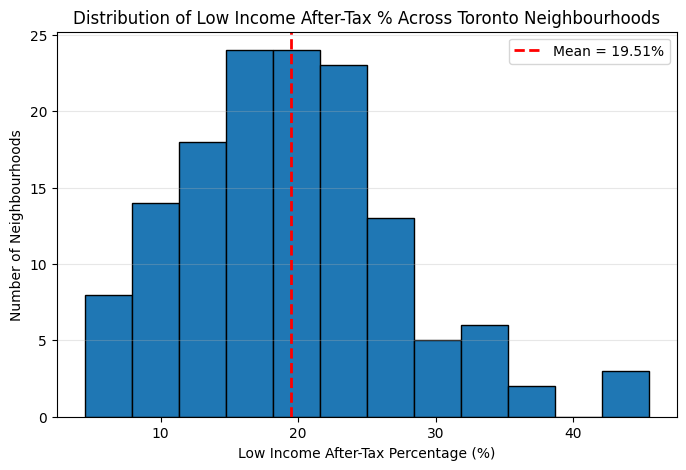

In [37]:
%matplotlib inline
import matplotlib.pyplot as plt

mean_lim = ml_ready["Low_Income_AfterTax_Pct"].mean()

fig, ax = plt.subplots(figsize=(8,5))

ax.hist(
    ml_ready["Low_Income_AfterTax_Pct"],
    bins=12,
    edgecolor="black")

ax.axvline(
    mean_lim,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_lim:.2f}%")

ax.set_title("Distribution of Low Income After-Tax % Across Toronto Neighbourhoods")
ax.set_xlabel("Low Income After-Tax Percentage (%)")
ax.set_ylabel("Number of Neighbourhoods")

ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.show()

the histogram illustrates the distribution of Low Income After-Tax Percentage (LIM-AT) across the 140 Toronto neighbourhoods included in the analysis. Consistent with the descriptive statistics presented in Table 6.1, most neighbourhoods are concentrated between approximately 15% and 25%, with the average low-income rate of 19.51% indicated by the red dashed line.

The distribution exhibits a slight right skew, with a small number of neighbourhoods experiencing substantially higher low-income rates than the majority. This suggests that while most Toronto neighbourhoods have moderate levels of low-income prevalence, a limited number face considerably greater socioeconomic challenges. The observed variation confirms that the response variable contains sufficient diversity to support subsequent Principal Component Analysis, cluster analysis, and predictive modelling.

### 8. Export Machine Learning Dataset

Following data preparation, feature extraction, restructuring, and validation, the finalized machine learning-ready dataset is exported for use in the subsequent stages of the capstone project.

The exported dataset serves as the standardized analytical input for all remaining notebooks, ensuring that feature relationship analysis, dimensionality reduction, clustering, predictive modelling, and temporal validation are performed using a consistent and reproducible neighbourhood-level dataset.

The exported dataset contains:

- **140 neighbourhood observations** (City of Toronto aggregate removed);
- **12 independent variables** representing demographic, socioeconomic, labour market, housing, education, immigration, and ethnocultural characteristics;
- **1 dependent variable** representing neighbourhood-level low-income prevalence (Low-Income After-Tax Percentage, LIA-Tax%), used as a **proxy indicator of neighbourhood socioeconomic vulnerability**;
- **1 identifier column** (Neighbourhood).

Independent Variables (X):

- Population
- Participation_Rate
- Employment_Rate
- Unemployment_Rate
- Bachelors_Degree
- No_Diploma
- Visible_Minority
- Renters
- Immigrant_Population
- Lone_Parent_Families
- Core_Housing_Need
- Unaffordable_Housing

Dependent Variable (Y):

- Low_Income_AfterTax_Pct

Exporting the dataset at this stage establishes a single, reproducible source of truth for all subsequent analyses and ensures methodological consistency throughout the capstone project.



In [38]:
output_path = "../../data/processed/neighbourhood_profiles_2016_ml_ready.csv"

ml_ready.to_csv(
    output_path,
    index=False)

print("=" * 60)
print("EXPORT COMPLETE")
print("=" * 60)

print(f"Dataset saved to:\n{output_path}")

print("\nDataset Shape:")
print(ml_ready.shape)

display(ml_ready.head())

EXPORT COMPLETE
Dataset saved to:
../../data/processed/neighbourhood_profiles_2016_ml_ready.csv

Dataset Shape:
(140, 14)


,Neighbourhood,Population,Participation_Rate,Employment_Rate,Unemployment_Rate,Bachelors_Degree,No_Diploma,Immigrant_Population,Visible_Minority,Renters,Core_Housing_Need,Unaffordable_Housing,Lone_Parent_Families,Low_Income_AfterTax_Pct
0,Agincourt North,29113,55.4,50.0,9.8,4380,7460,19995,26365,1720,2220,34.7,1650,21.3
1,Agincourt South-Malvern West,23757,59.0,53.2,9.8,4210,6090,15095,20155,2250,1795,38.2,1360,22.6
2,Alderwood,12054,66.5,62.4,6.1,1660,2960,3970,2490,950,540,21.7,670,8.2
3,Annex,30526,70.6,65.8,6.7,9135,4270,8270,7270,9870,2420,40.4,895,18.3
4,Banbury-Don Mills,27695,59.9,55.6,7.2,6500,5150,13195,12700,4735,2115,33.4,1255,13.7


### 9. Automated Data Profiling

Following the export of the finalized machine learning-ready dataset, an automated exploratory data analysis (EDA) is performed using **YData Profiling** to independently validate the exported analytical dataset.

The original Toronto Neighbourhood Profiles dataset was not suitable for automated profiling because it was organized with socioeconomic indicators as rows and neighbourhoods as columns, rather than following the conventional observation-by-variable structure expected by automated profiling tools. Consequently, manual exploratory data analysis was performed during the data preparation stage to understand the dataset structure, identify the required socioeconomic indicators, assess data quality, and prepare the dataset for transformation.

Once the dataset had been restructured into a machine learning-ready format, automated profiling became appropriate. Unlike the earlier manual exploratory analysis, **YData Profiling** provides a comprehensive assessment of the finalized dataset by generating descriptive statistics, variable distributions, correlation analysis, missing value diagnostics, duplicate detection, and data quality warnings.

This automated profiling step serves as an additional quality assurance procedure to verify that the exported dataset is complete, internally consistent, and suitable for subsequent statistical analyses and predictive modelling.

The generated HTML report is stored in the project's **reports** directory and serves as supplementary documentation supporting the reproducibility and quality assurance of this study.

In [39]:
from ydata_profiling import ProfileReport

In [40]:
validation_df = pd.read_csv(output_path)

profile = ProfileReport(
    validation_df,
    title="Toronto Neighbourhood Profile (2016) - Machine Learning Dataset",
    explorative=True)

print("=" * 60)
print("YDATA PROFILING")
print("=" * 60)
print("Profiling report generated successfully.")

YDATA PROFILING
Profiling report generated successfully.


In [41]:
report_path = "../../reports/Toronto_ML_Profile_Report_2016.html"

profile.to_file(report_path)

print("=" * 60)
print("REPORT SAVED")
print("=" * 60)
print(f"Location:\n{report_path}")


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 14/14 [00:00<00:00, 41.42it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

REPORT SAVED
Location:
../../reports/Toronto_ML_Profile_Report_2016.html


### Interpretation

The automated YData Profiling report successfully validated the exported machine learning-ready dataset. Unlike the original Toronto Neighbourhood Profiles dataset, which required manual exploratory analysis because of its indicator-oriented structure, the transformed dataset follows the conventional observation-by-variable format required for automated profiling.

The profiling report confirmed the dataset structure, variable distributions, descriptive statistics, missing values, duplicate observations, and correlation patterns. These findings verified that the data transformation process was successful and that the exported dataset is internally consistent and suitable for neighbourhood-level statistical analyses and predictive modelling.

The generated HTML report serves as supplementary quality assurance documentation, complementing the earlier manual exploratory data analysis and providing independent validation of the finalized analytical dataset.

### 10. Conclusion

### Summary

This notebook completed the data preparation and exploratory data analysis (EDA) phase of the project by transforming the raw 2016 Toronto Neighbourhood Profiles dataset into a structured machine learning-ready dataset suitable for neighbourhood-level statistical analysis and predictive modelling.

The original dataset required substantial preprocessing because it was organized with socioeconomic indicators as rows and neighbourhoods as columns rather than in the conventional observation-by-variable format. Consequently, manual exploratory data analysis was performed to understand the dataset structure, identify the required socioeconomic indicators, assess data quality, and prepare the data for transformation into a machine learning-ready format.

Following feature extraction and data restructuring, the dataset was transformed into a conventional analytical format consisting of neighbourhoods as observations and socioeconomic indicators as variables. Data quality was assessed through both manual validation procedures and an automated YData Profiling report, confirming that the finalized dataset contained the expected variable structure, appropriate data types, and no missing values within the selected variables.

The finalized machine learning-ready dataset consists of:

- **140 neighbourhood observations** (City of Toronto aggregate removed);
- **12 independent variables** representing demographic, socioeconomic, labour market, housing, education, immigration, and ethnocultural characteristics;
- **1 dependent variable**, **Low_Income_AfterTax_Pct**, representing neighbourhood-level low-income prevalence and used in this study as a **proxy indicator of neighbourhood socioeconomic vulnerability**;
- **1 identifier column** (Neighbourhood).

The finalized dataset has been exported as the standardized analytical input for all subsequent notebooks, ensuring a consistent, reproducible, and neighbourhood-level analytical workflow throughout the remainder of the capstone project.

## Project Analytical Workflow

```text
Raw Toronto Neighbourhood Profiles Dataset (2016)
        │
        ▼
Manual Exploratory Data Analysis
(CIND110; CIND123)
        │
        ▼
Feature Extraction & Variable Selection
(CMTH 642)
        │
        ▼
Data Cleaning, Validation & Transformation
(CIND110)
        │
        ▼
Machine Learning-Ready Dataset
(140 Neighbourhoods)
        │
        ▼
Automated YData Profiling
(Clemente et al., 2023)
        │
        ▼
Notebook 2
Feature Relationship Analysis
(CIND123)
        │
        ▼
Notebook 3
PCA & Neighbourhood Vulnerability Assessment
(CMTH 642 Jolliffe & Cadima, 2016;
MacQueen, 1967;
Everitt et al., 2011)
        │
        ▼
Notebook 4
Predictive Modelling
(Linear Regression & Random Forest)
        │
        ▼
Notebook 5
2011 Machine Learning Dataset Preparation
        │
        ▼
Notebook 6
Temporal Validation & Comparative Analysis
        │
        ▼
Notebook 7
Temporal Predictive Model Validation
```